In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [ ]:
results_snp=np.load("mi_map_snp_all.npy",allow_pickle=True)
results_btc=np.load("mi_map_btc_all.npy",allow_pickle=True)

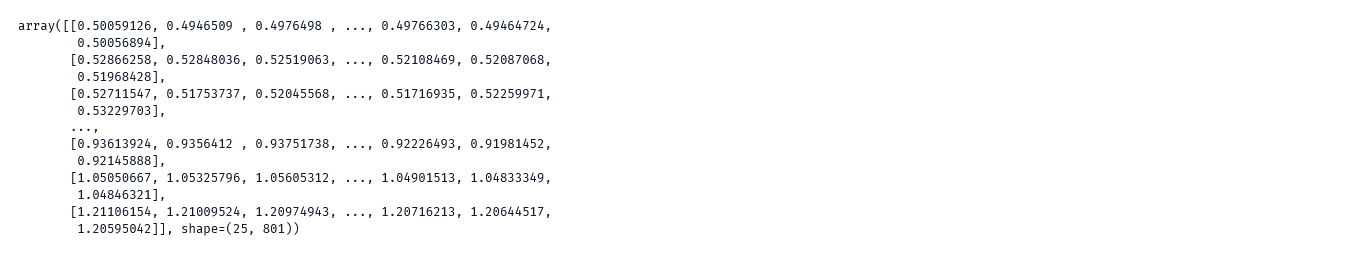

In [ ]:
results_snp[0]["S&P500"]["mi_map"]

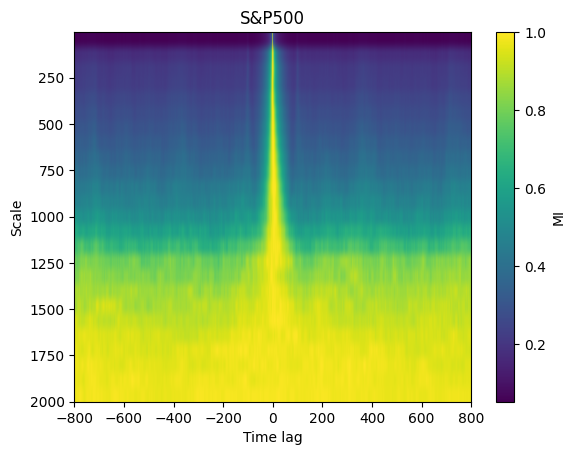

In [ ]:
plt.imshow(results_snp[0]["S&P500"]["mi_map_normalized"],aspect="auto",extent=[-800, 800, results_snp[0]["S&P500"]["scales"][-1], results_snp[0]["S&P500"]["scales"][0]])
plt.title("S&P500")
plt.xlabel('Time lag')
plt.ylabel('Scale')
plt.colorbar(label='MI')
plt.show()

In [ ]:
def smooth_mi_map(mi_map, sigma_scale=1.0, sigma_lag=2.0, alpha=0.0):
    """
    alpha = regularisation strength (0 = none)
    """
    smoothed = gaussian_filter(mi_map, sigma=[sigma_scale, sigma_lag])

    if alpha > 0:
        # Tikhonov regularisation: (I + αL)^(-1) M
        # Here: simple shrinkage toward smoothness
        smoothed = (1 - alpha) * smoothed + alpha * gaussian_filter(smoothed, sigma=3)

    return smoothed

In [ ]:
# input_map = results_snp[0]["S&P500"]["mi_map_normalized"]
# sigmas = [(0.8, 1.5), (1.0, 2.0), (1.2, 2.5)]
# ridges = []
# plt.imshow(input_map ,aspect="auto",extent=[-800, 800, results_snp[0]["S&P500"]["scales"][-1], results_snp[0]["S&P500"]["scales"][0]])
# plt.title("S&P500 input")
# plt.xlabel('Time lag')
# plt.ylabel('Scale')
# plt.colorbar(label='MI')
# plt.show()
# for s_scale, s_lag in sigmas:
#     sm = smooth_mi_map(input_map, s_scale, s_lag)
#     plt.imshow(sm ,aspect="auto",extent=[-800, 800, results_snp[0]["S&P500"]["scales"][-1], results_snp[0]["S&P500"]["scales"][0]])
#     plt.title("S&P500 smoothed")
#     plt.xlabel('Time lag')
#     plt.ylabel('Scale')
#     plt.colorbar(label='MI')
#     plt.show()

In [ ]:
def plot_comparison_with_ridges(input_map, scales, sigmas, lags, smooth_fn):
    """
    input_map : 2D MI map (scales × lags)
    scales    : array of scale values (top→bottom)
    sigmas    : list of (sigma_scale, sigma_lag)
    lags      : array of lag values
    smooth_fn : smoothing function, e.g. smooth_mi_map
    """

    # --- 1. Plot raw input ---
    plt.figure(figsize=(12, 5))
    plt.imshow(
        input_map,
        aspect="auto",
        extent=[lags[0], lags[-1], scales[-1], scales[0]],
        cmap="viridis"
    )
    plt.title("S&P500 — Raw MI map")
    plt.xlabel("Time lag")
    plt.ylabel("Scale")
    plt.colorbar(label="MI")
    plt.tight_layout()
    plt.show()

    # --- 2. Plot smoothed versions ---
    for (s_scale, s_lag) in sigmas:
        sm = smooth_fn(input_map, s_scale, s_lag)
        ridge = np.argmax(sm, axis=1)  # ridge index per scale
        print(ridge)
        ridge_lags = lags[ridge]

        plt.figure(figsize=(12, 5))
        plt.imshow(
            sm,
            aspect="auto",
            extent=[lags[0], lags[-1], scales[-1], scales[0]],
            cmap="viridis"
        )
        plt.plot(ridge_lags, scales, color="red", linewidth=2, label="Ridge")

        plt.title(f"S&P500 — Smoothed (σ_scale={s_scale}, σ_lag={s_lag})")
        plt.xlabel("Time lag")
        plt.ylabel("Scale")
        plt.colorbar(label="MI")
        plt.legend()
        plt.tight_layout()
        plt.show()


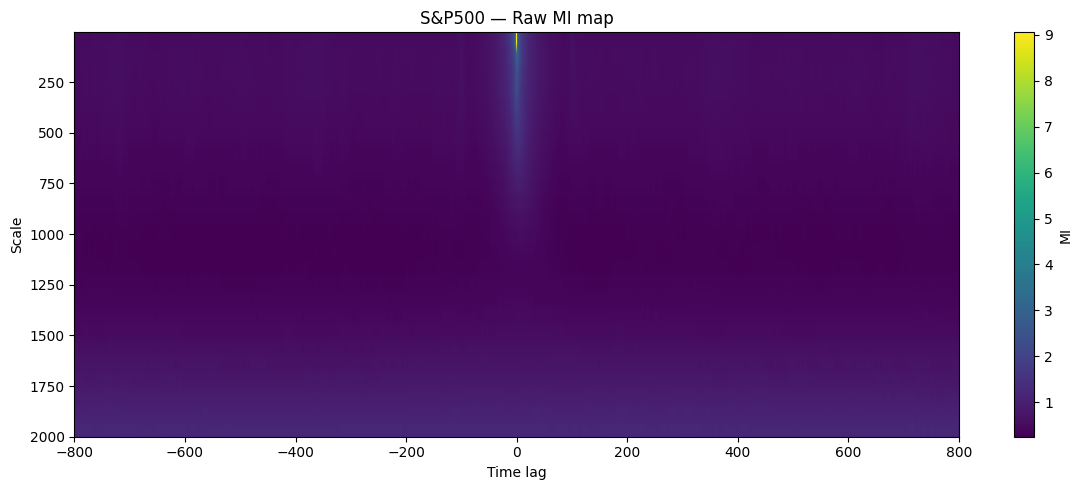

[400 400 400 400 400 401 401 401 402 402 403 403 404 404 403 399 399 401
 402 415 413 345 499 555 413]


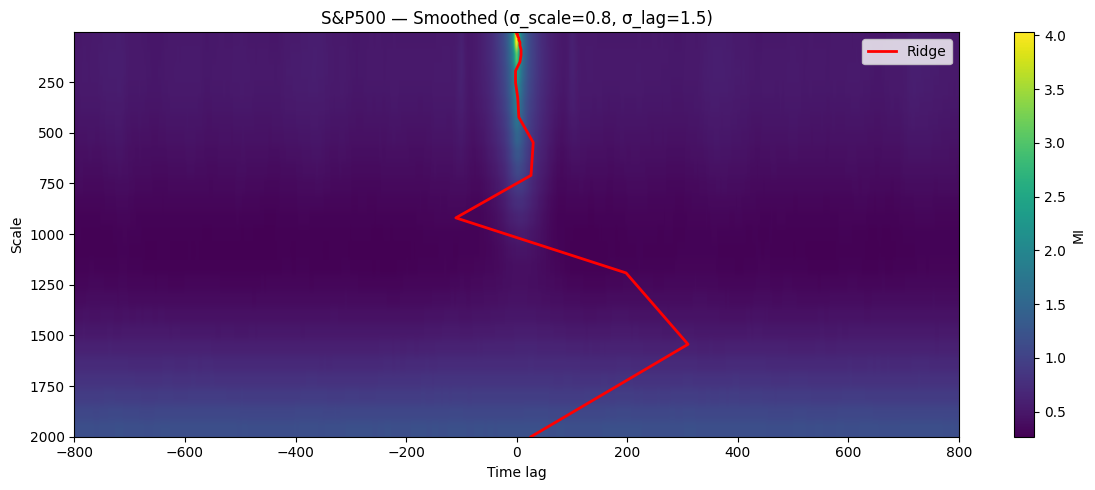

[400 400 400 400 400 401 401 401 402 402 403 403 404 404 404 400 400 401
 403 414 413 409 499 555 413]


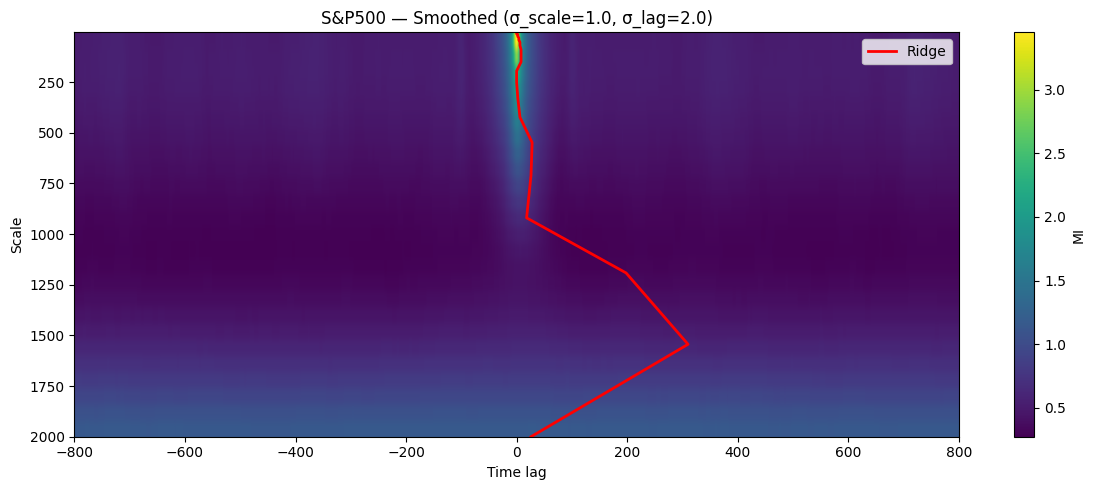

[400 400 400 400 400 401 401 401 402 402 403 403 404 404 404 401 400 402
 403 404 412 409 498 499 413]


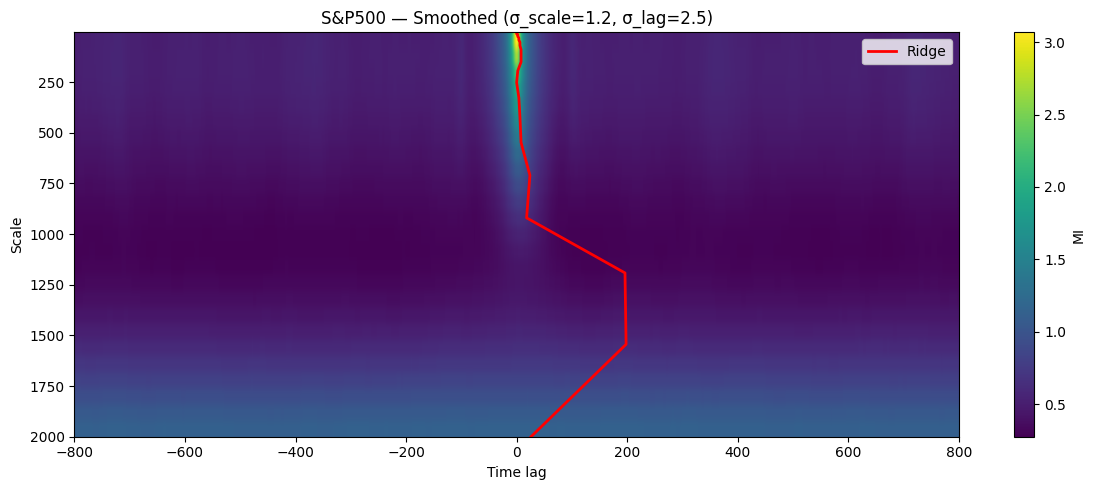

In [ ]:
input_map = results_snp[0]["S&P500"]["mi_map"]
scales = results_snp[0]["S&P500"]["scales"]
lags = np.linspace(-800, 800, 801)  # or your actual lag array

sigmas = [(0.8, 1.5), (1.0, 2.0), (1.2, 2.5)]

plot_comparison_with_ridges(
    input_map=input_map,
    scales=scales,
    sigmas=sigmas,
    lags=lags,
    smooth_fn=smooth_mi_map
)